## __Predicción de peso de diferentes especies de pescado con Regresión Lineal__

#### Realizado por *Elías Zorrilla Galdón*

Durante este notebook, vamos a utilizar una base de dtos que guarda las diferentes medidas de varias especies de pescado en relación a su peso para entrenar dos modelos distintos de machine learning:
- Un modelo de *Regresión múltiple exponencial*
- Un modelo de *Regresión polinomial*

Despues compararemos la eficacia de ambos modelos para predecir nuevos outputs con la utilización de __diferentes métricas de error estadistico__.

Primero importamos las librerias que vamos a utilizar

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

Leemos el archivo .csv y comprobamos su estructura y agrupamos los datos en base a las especies para ver el valor medio y  el máximo de cada una en las 
diferentes medidas estudiadas.

In [2]:
df = pd.read_csv('Fish.csv')

In [3]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [4]:
df.groupby('Species').agg('max')

,Weight,Length1,Length2,Length3,Height,Width
Species,,,,,,
Bream,1000.0,38.0,41.0,46.5,18.9570,6.7497
Parkki,300.0,24.0,26.0,29.0,11.3680,4.2340
Perch,1100.0,41.1,44.0,46.6,12.8002,8.1420
Pike,1650.0,59.0,63.4,68.0,10.8120,7.4800
Roach,390.0,29.5,31.7,35.0,9.4850,5.3550
Smelt,19.9,13.8,15.0,16.2,2.9322,2.0672
Whitefish,1000.0,37.3,40.0,43.5,12.3540,6.5736


In [5]:
df.groupby('Species').agg('mean')

,Weight,Length1,Length2,Length3,Height,Width
Species,,,,,,
Bream,617.828571,30.305714,33.108571,38.354286,15.183211,5.427614
Parkki,154.818182,18.727273,20.345455,22.790909,8.962427,3.220736
Perch,382.239286,25.735714,27.892857,29.571429,7.861870,4.745723
Pike,718.705882,42.476471,45.482353,48.717647,7.713771,5.086382
Roach,152.050000,20.645000,22.275000,24.970000,6.694795,3.657850
Smelt,11.178571,11.257143,11.921429,13.035714,2.209371,1.340093
Whitefish,531.000000,28.800000,31.316667,34.316667,10.027167,5.473050


In [6]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

Comprobamos que la columna 'Species' es cualitativa y para poder introducirla en nuestro análisis, decido convertirla a __one hot encoding__ creando diferentes dummy columns en un dataset llamado `df_ohe`. 

Para una buena interpretación de los coeficientes, necesitamos eliminar una de las columnas del One Hot Encoding para que no se dé la colinealidad perfecta.
(Al haber siete columnas de unos y el resto ceros, siempre hay una de ellas que por así decirlo sobra ya que no revela nueva información y es 1 menos la suma de las demás).
Es por esto que en vez de droppear la primera columna (`drop_first=True`) como suele hacerse normalmente, he eliminado la columna *'Whitefish'* ya que solo tiene 6 datos y es la que menos perjudica al resto del dataset al ser eliminada.

In [7]:
df_ohe = pd.get_dummies(df['Species'],dtype=int)
df_ohe = df_ohe.drop('Whitefish',axis =1)

Concateno `df` y `df_ohe` en el axis 1 creando asi el __DataFrame `fish`__ y elimino la columna 'Species'.

In [8]:
fish=pd.concat([df,df_ohe],axis=1)


In [9]:
fish = fish.drop('Species',axis=1)

In [10]:
fish.head()

,Weight,Length1,Length2,Length3,Height,Width,Bream,Parkki,Perch,Pike,Roach,Smelt
0,242.0,23.2,25.4,30.0,11.5200,4.0200,1,0,0,0,0,0
1,290.0,24.0,26.3,31.2,12.4800,4.3056,1,0,0,0,0,0
2,340.0,23.9,26.5,31.1,12.3778,4.6961,1,0,0,0,0,0
3,363.0,26.3,29.0,33.5,12.7300,4.4555,1,0,0,0,0,0
4,430.0,26.5,29.0,34.0,12.4440,5.1340,1,0,0,0,0,0


Ahora podemos pasar al análisis explorativo por lo que llamaremos a `sns.pairplot()` para hacer un poco de análisis explorativo y comprobar que tipo de relación hay entre las Features y la Respuesta.

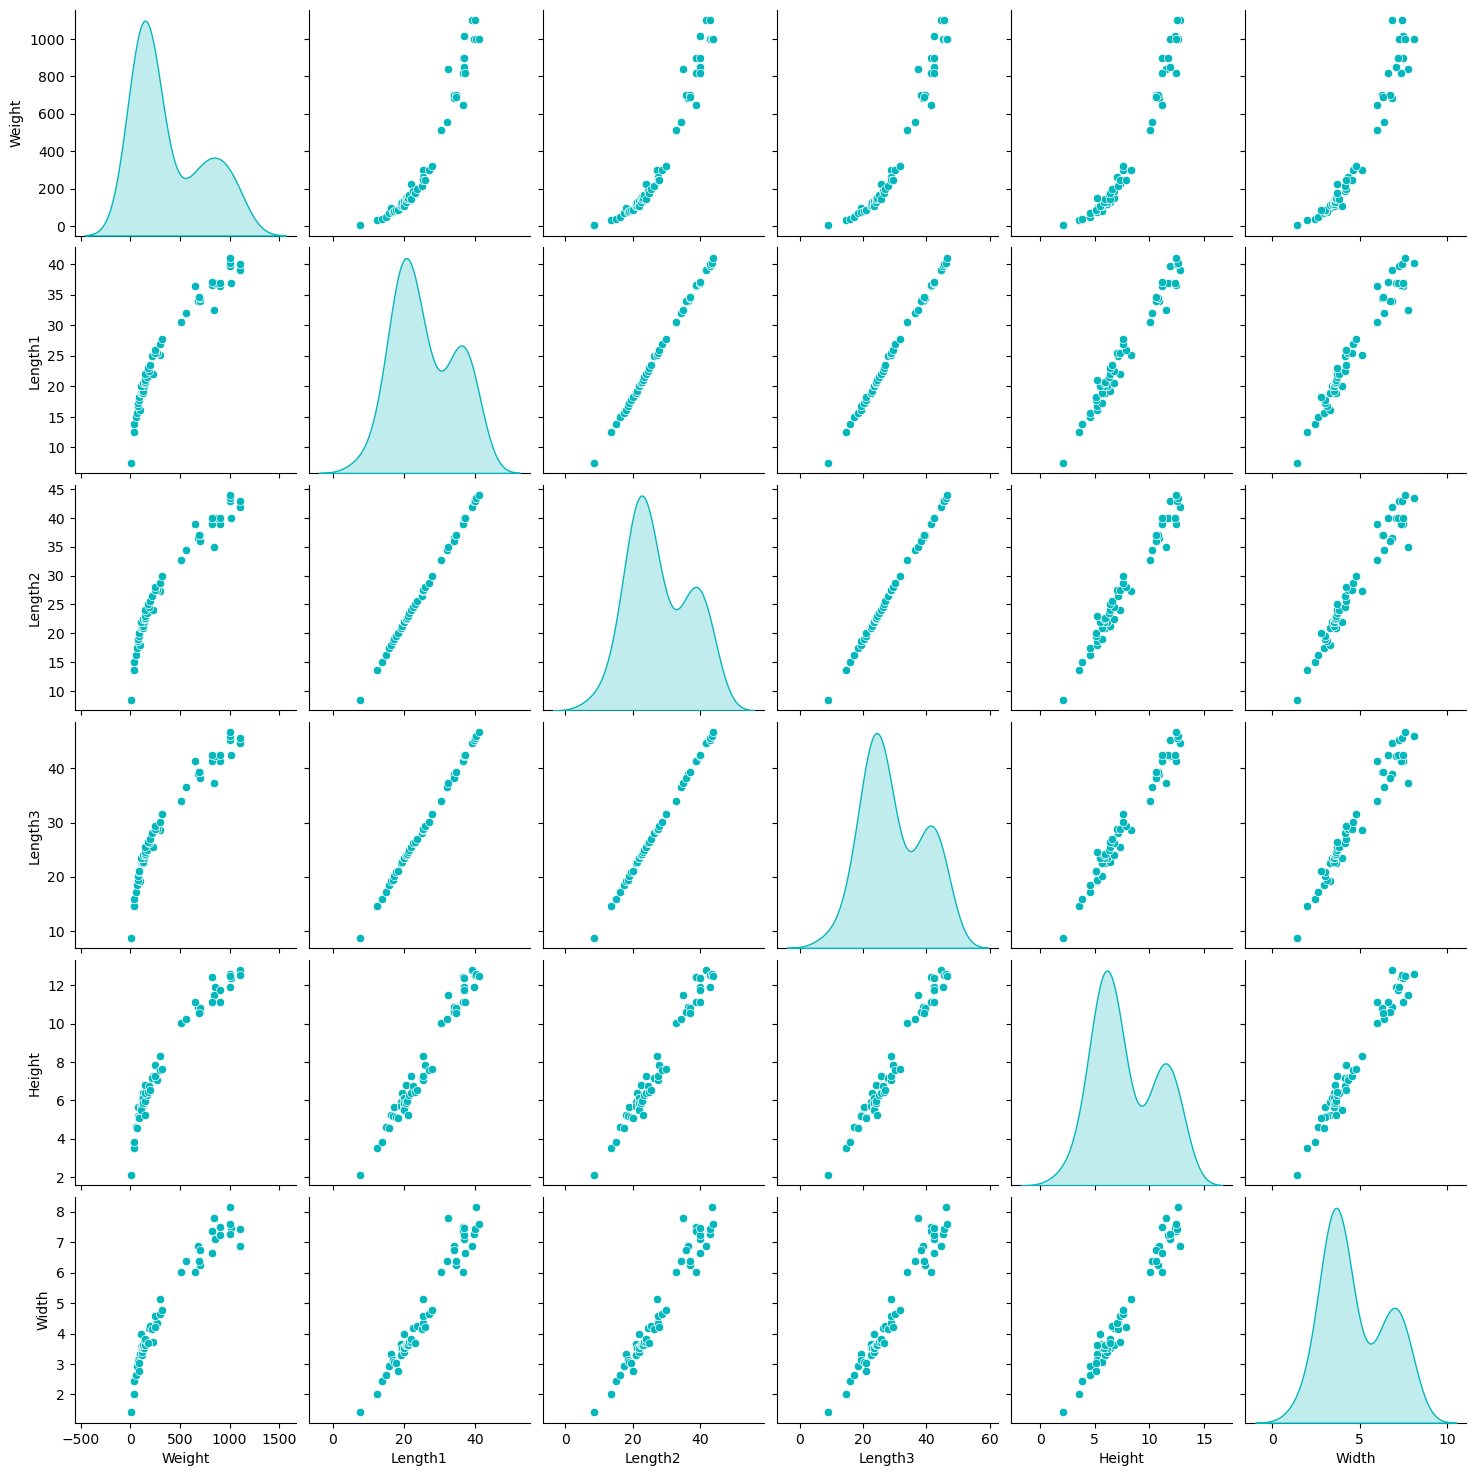

In [41]:
sns.pairplot(fish[fish['Perch']==1][['Weight','Length1','Length2','Length3','Height','Width']],diag_kind= 'kde' ,
             plot_kws={'color': '#04b7bd',},
             diag_kws={'color': '#04b7bd'})

En nuestro análisis podemos determinar que:
- __Features:__ Length1, Length2, Length3, Height,	Width, Bream, Parkki,	Perch, Pike, Roach, Smelt &	Whitefish
- __Response:__ Weight

Debido a que vamos a usar en la respuesta un ajuste logarítmico, necesitamos droppear cualquier fila en la que la respuesta sea <= 0.

In [12]:
fish = fish.loc[fish['Weight']>0,:]

Dividimos las features(X) de la respuesta(y), Importamos el `train/test split` y lo creamos con un `tamaño del test del 30%` y con un `random_state = 42`.

In [13]:
X = fish.drop('Weight',axis = 1)
y = fish.loc[:,'Weight']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression

Convertimos la respuesta en logarítmica para linealizar las gráficas y poder hacer una regresión linear.

y = a*e^bx
->
ln(y) = ln(a) + bx

 Y^  = B0 + B1X

That means that a = exp(B0), b = B1 and y = exp(Y^)

In [17]:
y_train_log = np.log(y_train)

Creo el modelo de regresión lineal, lo entreno con `.fit` y predigo el resultado con `.predict`

In [18]:
exp_model = LinearRegression()

In [19]:
exp_model.fit(X_train,y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
exp_prediction = exp_model.predict(X_test)

Devolvemos la respuesta al estado anterior, deshaciendo el ajuste logarítmico de antes

In [21]:
prediction = np.exp(exp_prediction)

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [23]:
MAE = mean_absolute_error(y_test,prediction)
MSE = mean_squared_error(y_test,prediction)
RMSE = root_mean_squared_error(y_test,prediction)
R2 = r2_score(y_test,prediction)

In [24]:
RMSE

147.40873606967511

In [25]:
residuals = y_test - prediction

Text(0, 0.5, 'Test residuals')

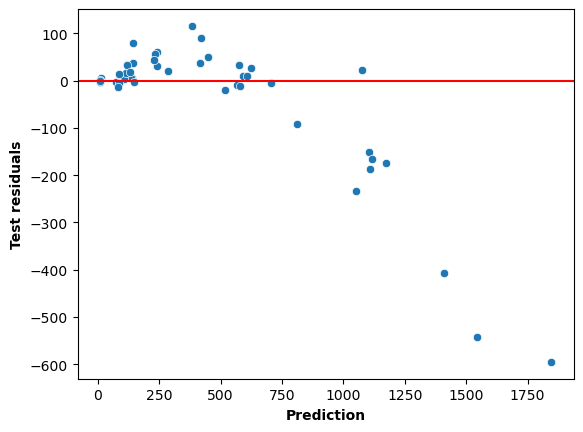

In [26]:
fig,axs = plt.subplots(1,1) 
sns.scatterplot(x=prediction,y=residuals,ax=axs)
axs.axhline(y=0, color='red', linestyle='-')
axs.set_xlabel("Prediction",fontweight = 900)
axs.set_ylabel("Test residuals",fontweight = 900)

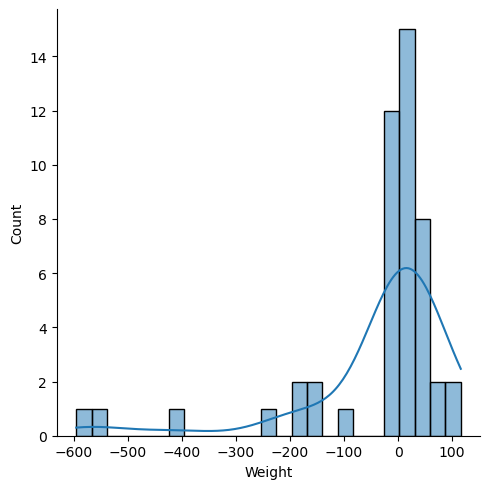

In [27]:
sns.displot(residuals,bins=25,kde=True)

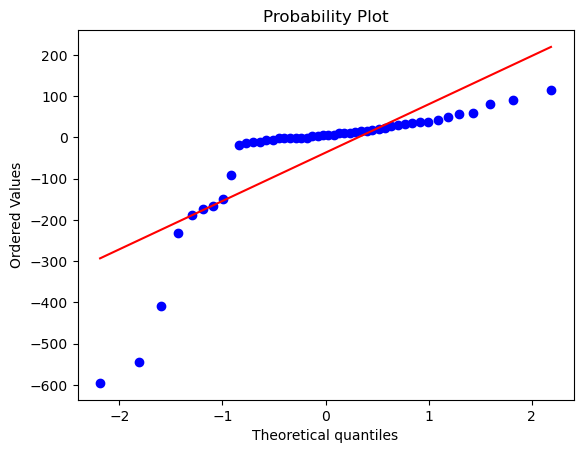

In [28]:
import scipy.stats as st

fig, ax  = plt.subplots(1,1)
_ = st.probplot(residuals,plot=ax)

In [29]:
log_pred = np.log(prediction)
log_y_test = np.log(y_test) 
test_residuals = log_y_test - log_pred

Text(0, 0.5, 'Test residuals')

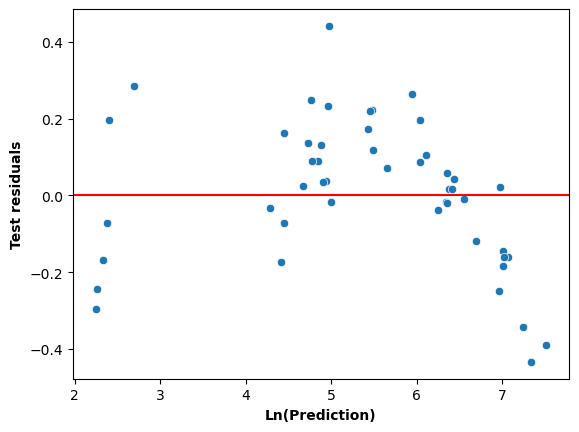

In [30]:
fig,axs = plt.subplots(1,1) 
sns.scatterplot(x=log_pred,y=test_residuals,ax=axs)
axs.axhline(y=0, color='red', linestyle='-')
axs.set_xlabel("Ln(Prediction)",fontweight = 900)
axs.set_ylabel("Test residuals",fontweight = 900)

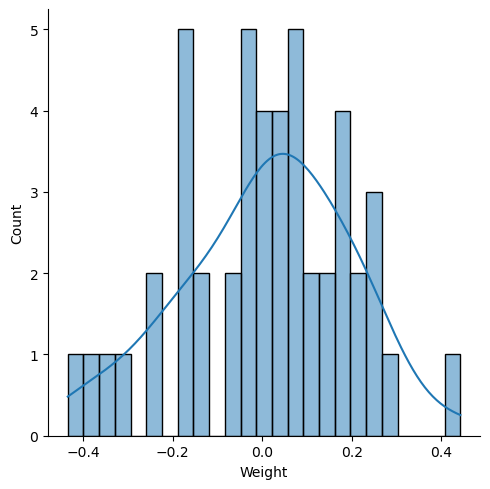

In [31]:
sns.displot(test_residuals,bins=25,kde=True)

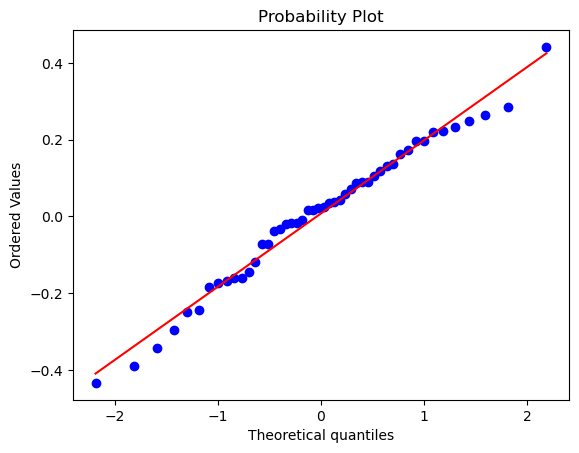

In [32]:
fig, ax  = plt.subplots(1,1)
_ = st.probplot(test_residuals,plot=ax)

Text(0, 0.5, 'Weight (g)')

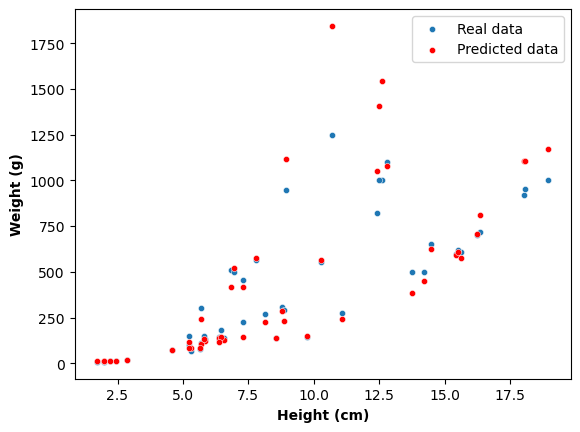

In [33]:
fig,axs = plt.subplots(1,1) 
sns.scatterplot(x=X_test['Height'],y=y_test,s=20,ax=axs,label = 'Real data') 
sns.scatterplot(x=X_test['Height'],y=prediction,s=20,color='red',ax=axs,label ='Predicted data')

axs.set_xlabel("Height (cm)",fontweight = 900)
axs.set_ylabel("Weight (g)",fontweight = 900)